## 1. Environment Setup & Google Drive Mount

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install xgboost shap -q

# Imports
import json
import re
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

from xgboost import XGBClassifier
import shap

# Base path
BASE = '/content/drive/MyDrive/ThePublicJiraDataset'
DUMP = BASE + '/3. DataDump'

print('Environment ready.')

Mounted at /content/drive
Environment ready.


## 2. Data Loading

In [2]:
# Load raw JSON files downloaded from Jira REST API
with open(f'{DUMP}/Apache_issues.json') as f:
    apache = json.load(f)
with open(f'{DUMP}/Jira_issues.json') as f:
    jira = json.load(f)
with open(f'{DUMP}/MongoDB_issues.json') as f:
    mongodb = json.load(f)

print(f'Apache:  {len(apache):,} issues')
print(f'Jira:    {len(jira):,} issues')
print(f'MongoDB: {len(mongodb):,} issues')
print(f'Total:   {len(apache)+len(jira)+len(mongodb):,} issues')

Apache:  10,000 issues
Jira:    2,000 issues
MongoDB: 8,000 issues
Total:   20,000 issues


## 3. Data Flattening & Preprocessing

In [3]:
def flatten_issue(issue, source):
    """Extract relevant fields from a raw Jira issue JSON object."""
    fields = issue.get('fields', {})
    return {
        'id':           issue.get('id'),
        'key':          issue.get('key'),
        'source':       source,
        'created':      fields.get('created'),
        'resolutiondate': fields.get('resolutiondate'),
        'status':       fields.get('status', {}).get('name') if fields.get('status') else None,
        'priority':     fields.get('priority', {}).get('name') if fields.get('priority') else None,
        'issuetype':    fields.get('issuetype', {}).get('name') if fields.get('issuetype') else None,
        'assignee':     fields.get('assignee', {}).get('displayName') if fields.get('assignee') else None,
        'story_points': (fields.get('customfield_12310293') or
                         fields.get('customfield_10555') or 0),
        'timespent':    fields.get('timespent') or 0,
        'summary':      fields.get('summary') or '',
        'description':  fields.get('description') or '',
    }

rows = []
for issue in apache:  rows.append(flatten_issue(issue, 'Apache'))
for issue in jira:    rows.append(flatten_issue(issue, 'Jira'))
for issue in mongodb: rows.append(flatten_issue(issue, 'MongoDB'))

df = pd.DataFrame(rows)
print(f'Raw DataFrame: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Raw DataFrame: (20000, 13)
Columns: ['id', 'key', 'source', 'created', 'resolutiondate', 'status', 'priority', 'issuetype', 'assignee', 'story_points', 'timespent', 'summary', 'description']


,id,key,source,created,resolutiondate,status,priority,issuetype,assignee,story_points,timespent,summary,description
0,12705174,SPARK-515,Apache,0010-04-03T23:04:00.000+0000,2012-10-19T22:50:39.000+0000,Resolved,None,Bug,None,0.0,0,Make it easier to run external code on a Nexus...,"Right now, one must modify the Makefile and ru..."
1,12705172,SPARK-514,Apache,0010-04-03T23:05:00.000+0000,2012-10-19T22:50:36.000+0000,Resolved,None,Bug,None,0.0,0,Merge fault tolerance code into master branch,
2,12705483,SPARK-513,Apache,0010-04-03T23:06:00.000+0000,2012-10-19T22:50:22.000+0000,Resolved,None,Bug,None,0.0,0,Make NexusScheduler more efficient by keeping ...,"Right now, it performs an O(N) scan to find lo..."


## 4. Issue Type Filtering

In [4]:
# Check issue type distribution
print('=== Issue Type Distribution ===')
print(df['issuetype'].value_counts())

# Keep only delivery-relevant issue types
# Exclude: Question, Wish, Support Request (no delivery timelines)
# Retain: Sub-task (atomic delivery units tied to sprint completion)
keep_types = ['Bug', 'Improvement', 'Task', 'New Feature', 'Suggestion', 'Sub-task']
df = df[df['issuetype'].isin(keep_types)].copy()

print(f'\nAfter filtering: {len(df):,} issues')
print(df['issuetype'].value_counts())

=== Issue Type Distribution ===
issuetype
Bug                12541
Improvement         3251
Task                2001
New Feature         1037
Suggestion          1017
Question             134
Sub-task              13
Wish                   3
Support Request        3
Name: count, dtype: int64

After filtering: 19,860 issues
issuetype
Bug            12541
Improvement     3251
Task            2001
New Feature     1037
Suggestion      1017
Sub-task          13
Name: count, dtype: int64


## 5. Delay Label Engineering (Corrected)

**Three strategies evaluated:**
- Strategy 1 (estimate-based): Only 85 issues had time estimates (infeasible)
- Strategy 2 (due-date-based): Only 9 issues had due dates (infeasible)  
- Strategy 3 (median-based): Adopted with correction

**Correction rationale:**  
An initial pooled median across all repositories systematically over-labelled Apache issues as delayed (Apache has longer resolution times due to open-source volunteer model). This caused `source_enc` to emerge as the top SHAP predictor(a label artefact), not a genuine signal  
The corrected label computes the median **per repository per issue type**

In [5]:
# Convert date columns
df['created'] = pd.to_datetime(df['created'], utc=True, errors='coerce')
df['resolutiondate'] = pd.to_datetime(df['resolutiondate'], utc=True, errors='coerce')

# Calculate actual resolution time in days
df['actual_days'] = (
    (df['resolutiondate'] - df['created']).dt.total_seconds() / 86400
)

# CORRECTED delay label: per repository per issue type median
median_days = df.groupby(['source', 'issuetype'])['actual_days'].transform('median')
df['is_delayed'] = (
    (df['actual_days'] > median_days * 1.5) &
    df['actual_days'].notna()
).astype(int)

print('=== Corrected Delay Label Distribution ===')
print(df['is_delayed'].value_counts())
print(f'\nOverall delay rate: {df["is_delayed"].mean():.1%}')

print('\n=== Delay Rate by Repository (should reflect genuine patterns) ===')
print(df.groupby('source')['is_delayed'].mean().round(3))

print('\n=== Delay Rate by Issue Type ===')
print(df.groupby('issuetype')['is_delayed'].mean().round(3))

=== Corrected Delay Label Distribution ===
is_delayed
0    13808
1     6052
Name: count, dtype: int64

Overall delay rate: 30.5%

=== Delay Rate by Repository (should reflect genuine patterns) ===
source
Apache     0.246
Jira       0.424
MongoDB    0.349
Name: is_delayed, dtype: float64

=== Delay Rate by Issue Type ===
issuetype
Bug            0.334
Improvement    0.300
New Feature    0.405
Sub-task       0.231
Suggestion     0.416
Task           0.020
Name: is_delayed, dtype: float64


/tmp/ipykernel_700/1023665906.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created'] = pd.to_datetime(df['created'], utc=True, errors='coerce')


## 6. Structured Feature Engineering

In [6]:
# Temporal features from created date
df['created_hour']      = df['created'].dt.hour
df['created_dayofweek'] = df['created'].dt.dayofweek
df['created_month']     = df['created'].dt.month
df['created_year']      = df['created'].dt.year

# Categorical encodings
df['priority_enc']   = df['priority'].astype('category').cat.codes
df['issuetype_enc']  = df['issuetype'].astype('category').cat.codes
df['source_enc']     = df['source'].astype('category').cat.codes

# Numeric features
df['story_points'] = pd.to_numeric(df['story_points'], errors='coerce').fillna(0)
df['timespent']    = pd.to_numeric(df['timespent'], errors='coerce').fillna(0)

# NOTE: actual_days is EXCLUDED to prevent target leakage
# (the delay label is derived from actual_days — including it gives AUC-ROC 1.0)

STRUCTURED_COLS = [
    'created_hour', 'created_dayofweek', 'created_month', 'created_year',
    'priority_enc', 'issuetype_enc', 'source_enc',
    'story_points', 'timespent'
]

# Drop rows with missing structured features
df_clean = df[STRUCTURED_COLS + ['summary', 'description', 'is_delayed']].dropna(subset=STRUCTURED_COLS)
df_clean['summary']     = df_clean['summary'].fillna('')
df_clean['description'] = df_clean['description'].fillna('')

print(f'Clean dataset: {df_clean.shape}')
print(f'Delayed: {df_clean["is_delayed"].sum():,} ({df_clean["is_delayed"].mean():.1%})')
print(f'On-time: {(df_clean["is_delayed"]==0).sum():,}')
print(f'\nDescription coverage: {(df_clean["description"].str.len() > 0).sum():,} issues')
print(f'Average description length: {df_clean["description"].str.len().mean():.0f} chars')
print(f'Average summary length: {df_clean["summary"].str.len().mean():.0f} chars')

Clean dataset: (19571, 12)
Delayed: 6,052 (30.9%)
On-time: 13,519

Description coverage: 18,482 issues
Average description length: 1009 chars
Average summary length: 49 chars


## 7. NLP Feature Engineering (TF-IDF)

Issue descriptions average **1,000 characters** (vs 49 for summaries), providing rich text signal.  
Text is preprocessed and combined, then vectorized with TF-IDF.

In [7]:
def clean_text(text):
    """Preprocess text: remove URLs, non-alpha chars, normalise whitespace."""
    text = str(text) if text else ''
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()   # normalise whitespace
    return text.lower()

# Combine summary + description
df_clean = df_clean.copy()
df_clean['text'] = (
    df_clean['summary'].apply(clean_text) + ' ' +
    df_clean['description'].apply(clean_text)
)

# Domain-specific stop words: project names that encode source identity, not delay signal
# These caused vocabulary leakage in the initial TF-IDF model (AUC-ROC inflated to 0.8482)
PROJECT_STOPWORDS = [
    # Apache sub-projects
    'struts', 'axis', 'cocoon', 'xerces', 'lucene', 'hadoop', 'spark', 'kafka',
    'maven', 'ant', 'tomcat', 'camel', 'commons', 'felix', 'wicket', 'tapestry',
    'turbine', 'velocity', 'james', 'poi', 'hbase', 'zookeeper', 'cassandra',
    'accumulo', 'hive', 'pig', 'oozie', 'solr', 'nutch', 'tika', 'cxf',
    'nifi', 'flink', 'beam', 'arrow', 'avro', 'thrift',
    # MongoDB specific
    'mongoid', 'mongo', 'mongodb', 'mgo', 'bson',
    # Atlassian specific
    'jira', 'confluence', 'atlassian', 'bamboo', 'bitbucket',
    # Technology identifiers
    'svn', 'xsl', 'xsd', 'dtd', 'wsdl', 'soap', 'fo',
    # Version references
    'version', 'release', 'snapshot', 'patch', 'branch', 'trunk',
]

CUSTOM_STOP = list(ENGLISH_STOP_WORDS) + PROJECT_STOPWORDS

# TF-IDF vectoriser (cleaned)
tfidf_clean = TfidfVectorizer(
    max_features=100,
    stop_words=CUSTOM_STOP,
    ngram_range=(1, 2),
    min_df=5
)
X_text_clean = tfidf_clean.fit_transform(df_clean['text'])

print(f'TF-IDF features (cleaned): {X_text_clean.shape[1]}')
print('\nTop 30 TF-IDF terms after cleaning:')
print(tfidf_clean.get_feature_names_out()[:30])

TF-IDF features (cleaned): 100

Top 30 TF-IDF terms after cleaning:
['accid' 'accid sid' 'add' 'apache' 'apache catalina' 'attribute' 'bin'
 'block' 'build' 'catalina' 'catalina core' 'change' 'class' 'code' 'com'
 'conn' 'conn update' 'core' 'data' 'db' 'document' 'does' 'element' 'end'
 'error' 'exception' 'failed' 'failed staleconfigexception' 'feb'
 'feb conn']


## 8. Train-Test Split

In [8]:
X_struct = df_clean[STRUCTURED_COLS].values
y = df_clean['is_delayed'].values

# Combined feature matrix (structured + cleaned TF-IDF)
X_combined = sp.hstack([X_struct, X_text_clean]).toarray()

# Structured-only split
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_struct, y, test_size=0.2, random_state=42, stratify=y)

# Combined split
X_train_c, X_test_c, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

print(f'Structured features: {X_struct.shape[1]}')
print(f'TF-IDF features:     {X_text_clean.shape[1]}')
print(f'Combined features:   {X_combined.shape[1]}')
print(f'Train size: {X_train_s.shape[0]:,}')
print(f'Test size:  {X_test_s.shape[0]:,}')
print(f'Delayed in test: {y_test.sum():,} ({y_test.mean():.1%})')

Structured features: 9
TF-IDF features:     100
Combined features:   109
Train size: 15,656
Test size:  3,915
Delayed in test: 1,211 (30.9%)


## 9. Baseline Models (Logistic Regression & Random Forest)

In [9]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled  = scaler.transform(X_test_s)

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

print('=== Logistic Regression (Structured Only) ===')
print(classification_report(y_test, y_pred_lr))
print(f'AUC-ROC: {auc_lr:.4f}')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test_s)[:,1])

print('\n=== Random Forest (Structured Only) ===')
print(classification_report(y_test, y_pred_rf))
print(f'AUC-ROC: {auc_rf:.4f}')

=== Logistic Regression (Structured Only) ===
              precision    recall  f1-score   support

           0       0.70      0.93      0.80      2704
           1       0.45      0.13      0.20      1211

    accuracy                           0.68      3915
   macro avg       0.58      0.53      0.50      3915
weighted avg       0.62      0.68      0.62      3915

AUC-ROC: 0.6840

=== Random Forest (Structured Only) ===
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2704
           1       0.54      0.47      0.50      1211

    accuracy                           0.71      3915
   macro avg       0.66      0.65      0.65      3915
weighted avg       0.70      0.71      0.71      3915

AUC-ROC: 0.7646


## 10. Advanced Baseline: XGBoost (Structured Only)

In [10]:
xgb_struct = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_struct.fit(X_train_s, y_train)
y_pred_xgb_s = xgb_struct.predict(X_test_s)
auc_xgb_s = roc_auc_score(y_test, xgb_struct.predict_proba(X_test_s)[:,1])

print('=== XGBoost (Structured Only) ===')
print(classification_report(y_test, y_pred_xgb_s))
print(f'AUC-ROC: {auc_xgb_s:.4f}')

=== XGBoost (Structured Only) ===
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      2704
           1       0.59      0.41      0.48      1211

    accuracy                           0.73      3915
   macro avg       0.68      0.64      0.65      3915
weighted avg       0.71      0.73      0.71      3915

AUC-ROC: 0.7917


## 11. Intermediate Model: XGBoost + TF-IDF (Uncleaned)
**Note:** This model uses uncleaned TF-IDF features. SHAP analysis (Section 12) reveals vocabulary leakage.

In [11]:
# Uncleaned TF-IDF (summary + description, standard English stop words only)
tfidf_raw = TfidfVectorizer(
    max_features=100, stop_words='english', ngram_range=(1, 2)
)
X_text_raw = tfidf_raw.fit_transform(df_clean['text'])
X_combined_raw = sp.hstack([X_struct, X_text_raw]).toarray()

X_train_r, X_test_r, _, _ = train_test_split(
    X_combined_raw, y, test_size=0.2, random_state=42, stratify=y)

xgb_raw = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_raw.fit(X_train_r, y_train)
y_pred_raw = xgb_raw.predict(X_test_r)
auc_raw = roc_auc_score(y_test, xgb_raw.predict_proba(X_test_r)[:,1])

print('=== XGBoost + TF-IDF (Uncleaned) ===')
print(classification_report(y_test, y_pred_raw))
print(f'AUC-ROC: {auc_raw:.4f}')
print('\nNOTE: High AUC-ROC partly due to project name vocabulary leakage (see Section 12)')

=== XGBoost + TF-IDF (Uncleaned) ===
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      2704
           1       0.68      0.47      0.55      1211

    accuracy                           0.77      3915
   macro avg       0.73      0.68      0.70      3915
weighted avg       0.76      0.77      0.75      3915

AUC-ROC: 0.8482

NOTE: High AUC-ROC partly due to project name vocabulary leakage (see Section 12)


## 12. Vocabulary Leakage Analysis

SHAP analysis of the uncleaned model reveals project name terms (struts, axis, cocoon, xerces, mongoid), encoding source identity rather than genuine delay signal, analogous to target leakage.

In [12]:
# Quick check: what are the top TF-IDF terms in uncleaned model?
raw_feature_names = STRUCTURED_COLS + [f'tfidf_{t}' for t in tfidf_raw.get_feature_names_out()]

explainer_raw = shap.TreeExplainer(xgb_raw)
shap_vals_raw = explainer_raw.shap_values(X_test_r)

# Get mean absolute SHAP values
mean_shap = np.abs(shap_vals_raw).mean(axis=0)
top_idx = np.argsort(mean_shap)[::-1][:20]

print('=== Top 20 Features in Uncleaned TF-IDF Model ===')
print('(Project name terms highlighted as leakage sources)')
for i, idx in enumerate(top_idx):
    name = raw_feature_names[idx]
    flag = ' *** LEAKAGE (project name)' if any(p in name for p in PROJECT_STOPWORDS) else ''
    print(f'  {i+1:2d}. {name:<35} SHAP={mean_shap[idx]:.4f}{flag}')

=== Top 20 Features in Uncleaned TF-IDF Model ===
(Project name terms highlighted as leakage sources)
   1. priority_enc                        SHAP=0.7174
   2. issuetype_enc                       SHAP=0.5312
   3. created_year                        SHAP=0.2804
   4. tfidf_fo                            SHAP=0.1542 *** LEAKAGE (project name)
   5. tfidf_struts                        SHAP=0.1053 *** LEAKAGE (project name)
   6. created_month                       SHAP=0.1042
   7. tfidf_axis                          SHAP=0.0802 *** LEAKAGE (project name)
   8. tfidf_cocoon                        SHAP=0.0645 *** LEAKAGE (project name)
   9. tfidf_server                        SHAP=0.0578
  10. created_hour                        SHAP=0.0492
  11. tfidf_does                          SHAP=0.0476
  12. tfidf_element                       SHAP=0.0419
  13. tfidf_svn                           SHAP=0.0405 *** LEAKAGE (project name)
  14. tfidf_using                         SHAP=0.0394
  15. t

## 13. Best Model: XGBoost + TF-IDF (Cleaned)

In [13]:
xgb_best = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_best.fit(X_train_c, y_train)
y_pred_best = xgb_best.predict(X_test_c)
auc_best = roc_auc_score(y_test, xgb_best.predict_proba(X_test_c)[:,1])

print('=== XGBoost + TF-IDF (Cleaned — Best Model) ===')
print(classification_report(y_test, y_pred_best))
print(f'AUC-ROC: {auc_best:.4f}')

=== XGBoost + TF-IDF (Cleaned — Best Model) ===
              precision    recall  f1-score   support

           0       0.78      0.89      0.83      2704
           1       0.64      0.44      0.52      1211

    accuracy                           0.75      3915
   macro avg       0.71      0.67      0.68      3915
weighted avg       0.74      0.75      0.74      3915

AUC-ROC: 0.8265


## 14. TF-IDF Ablation Study Summary

In [14]:
# Summary only TF-IDF (ablation)
df_clean['summary_only'] = df_clean['summary'].apply(clean_text)
tfidf_summ = TfidfVectorizer(max_features=50, stop_words=CUSTOM_STOP, ngram_range=(1,2))
X_text_summ = tfidf_summ.fit_transform(df_clean['summary_only'])
X_summ = sp.hstack([X_struct, X_text_summ]).toarray()
X_train_summ, X_test_summ, _, _ = train_test_split(X_summ, y, test_size=0.2, random_state=42, stratify=y)

xgb_summ = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_summ.fit(X_train_summ, y_train)
auc_summ = roc_auc_score(y_test, xgb_summ.predict_proba(X_test_summ)[:,1])

print('=' * 65)
print('TF-IDF ABLATION STUDY')
print('=' * 65)
print(f'{"Configuration":<42} {"AUC-ROC":>8} {"Gain":>8}')
print('-' * 65)
print(f'{"1. Structured only (9 features)":<42} {auc_xgb_s:>8.4f} {"baseline":>8}')
print(f'{"2. + Summary TF-IDF (59 features)":<42} {auc_summ:>8.4f} {f"+{auc_summ-auc_xgb_s:.4f}":>8}')
print(f'{"3. + Full TF-IDF uncleaned (109)":<42} {auc_raw:>8.4f} {f"+{auc_raw-auc_xgb_s:.4f}":>8}')
print(f'{"4. + Full TF-IDF cleaned (109)":<42} {auc_best:>8.4f} {f"+{auc_best-auc_xgb_s:.4f}":>8}')
print('-' * 65)
print(f'Genuine text contribution:  {auc_best - auc_xgb_s:.4f} AUC-ROC points')
print(f'Leakage contribution:       {auc_raw - auc_best:.4f} AUC-ROC points')
print(f'Summary-only contribution:  {auc_summ - auc_xgb_s:.4f} AUC-ROC points (negligible)')

TF-IDF ABLATION STUDY
Configuration                               AUC-ROC     Gain
-----------------------------------------------------------------
1. Structured only (9 features)              0.7917 baseline
2. + Summary TF-IDF (59 features)            0.7960  +0.0043
3. + Full TF-IDF uncleaned (109)             0.8482  +0.0565
4. + Full TF-IDF cleaned (109)               0.8265  +0.0348
-----------------------------------------------------------------
Genuine text contribution:  0.0348 AUC-ROC points
Leakage contribution:       0.0217 AUC-ROC points
Summary-only contribution:  0.0043 AUC-ROC points (negligible)


## 15. SHAP Explainability (Structured Only Model)

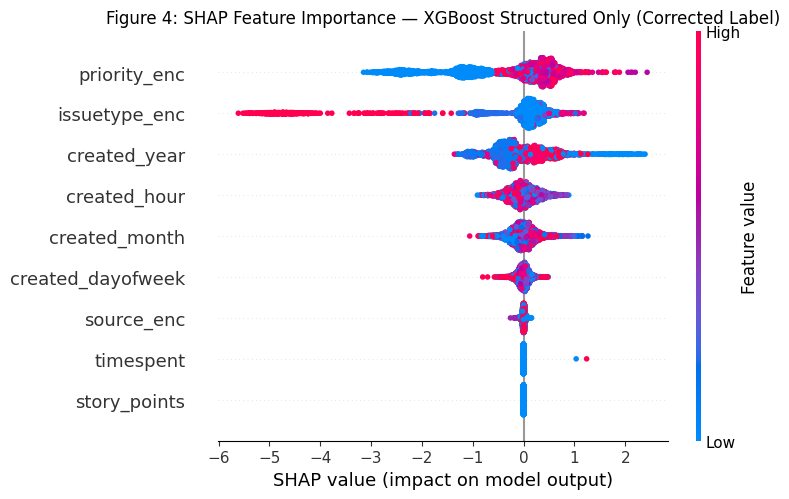

Figure 4 saved to Google Drive.

Note: source_enc should rank 7th — confirming absence of label bias.


In [15]:
explainer_struct = shap.TreeExplainer(xgb_struct)
shap_vals_struct = explainer_struct.shap_values(X_test_s)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_struct, X_test_s,
    feature_names=STRUCTURED_COLS,
    show=False
)
plt.title('Figure 4: SHAP Feature Importance — XGBoost Structured Only (Corrected Label)')
plt.tight_layout()
plt.savefig(f'{BASE}/shap_summary_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved to Google Drive.')
print('\nNote: source_enc should rank 7th — confirming absence of label bias.')

## 16. SHAP Explainability (Best Model)

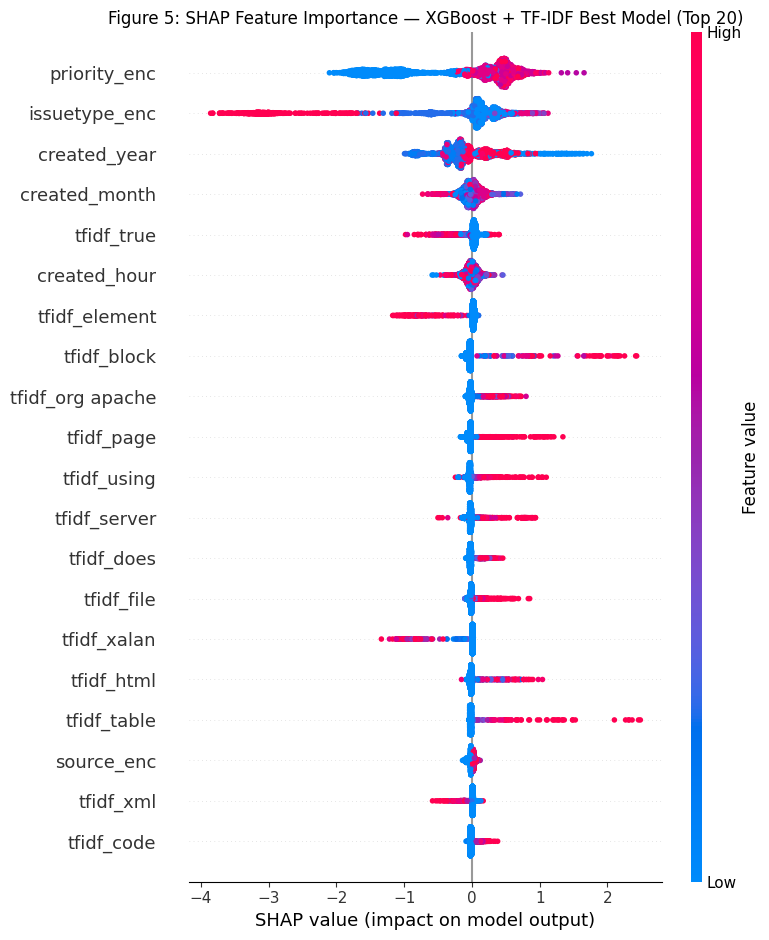

Figure 5 saved to Google Drive.


In [16]:
# Feature names for combined model
tfidf_feature_names = [f'tfidf_{t}' for t in tfidf_clean.get_feature_names_out()]
ALL_FEATURE_NAMES = STRUCTURED_COLS + tfidf_feature_names

explainer_best = shap.TreeExplainer(xgb_best)
shap_vals_best = explainer_best.shap_values(X_test_c)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals_best, X_test_c,
    feature_names=ALL_FEATURE_NAMES,
    max_display=20,
    show=False
)
plt.title('Figure 5: SHAP Feature Importance — XGBoost + TF-IDF Best Model (Top 20)')
plt.tight_layout()
plt.savefig(f'{BASE}/shap_summary_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved to Google Drive.')

## 17. Mitigation Mapping (RQ3)

In [17]:
mitigation_module = {
    1: {
        'feature':  'priority_enc',
        'finding':  'Lower-priority issues accumulate delay through systematic deprioritisation',
        'pmbok':    'Scope Management: re-prioritise backlog regularly; deprioritised items age and delay',
        'safe':     'Program Backlog: apply WSJF to explicitly defer rather than passively delay low-value items'
    },
    2: {
        'feature':  'issuetype_enc',
        'finding':  'Bugs and New Features delay more than Tasks due to inherent complexity and unpredictability',
        'pmbok':    'Quality Management: implement defect prevention strategies to reduce bug accumulation',
        'safe':     'Built-in Quality: enforce Definition of Done to prevent bugs entering sprint without resolution path'
    },
    3: {
        'feature':  'created_year',
        'finding':  'Older issues are significantly more likely to be delayed regardless of type or priority',
        'pmbok':    'Schedule Management: implement issue age limits and automatic escalation triggers',
        'safe':     'Iteration Planning: review and close or reassign issues older than two sprints'
    },
    4: {
        'feature':  'tfidf: failed / error / exception',
        'finding':  'Failure and exception vocabulary in issue descriptions signals high delay risk',
        'pmbok':    'Risk Management: flag issues with failure-language descriptions for immediate triage',
        'safe':     'Team Kanban: auto-tag issues containing failure keywords for next-sprint prioritisation review'
    },
    5: {
        'feature':  'created_hour',
        'finding':  'Issues created outside core working hours are at higher delay risk',
        'pmbok':    'Resource Management: review after-hours issue creation patterns as a team workload signal',
        'safe':     'Team Kanban: flag off-peak-hour issues for explicit next-sprint triage'
    }
}

print('=== RQ3: SHAP-to-Mitigation Mapping (Best Model) ===\n')
for rank, m in mitigation_module.items():
    print(f'Rank {rank}: {m["feature"]}')
    print(f'  Finding: {m["finding"]}')
    print(f'  PMBOK:   {m["pmbok"]}')
    print(f'  SAFe:    {m["safe"]}')
    print()

=== RQ3: SHAP-to-Mitigation Mapping (Best Model) ===

Rank 1: priority_enc
  Finding: Lower-priority issues accumulate delay through systematic deprioritisation
  PMBOK:   Scope Management: re-prioritise backlog regularly; deprioritised items age and delay
  SAFe:    Program Backlog: apply WSJF to explicitly defer rather than passively delay low-value items

Rank 2: issuetype_enc
  Finding: Bugs and New Features delay more than Tasks due to inherent complexity and unpredictability
  PMBOK:   Quality Management: implement defect prevention strategies to reduce bug accumulation
  SAFe:    Built-in Quality: enforce Definition of Done to prevent bugs entering sprint without resolution path

Rank 3: created_year
  Finding: Older issues are significantly more likely to be delayed regardless of type or priority
  PMBOK:   Schedule Management: implement issue age limits and automatic escalation triggers
  SAFe:    Iteration Planning: review and close or reassign issues older than two sprints



## 18. Final Results Summary

In [18]:
from sklearn.metrics import f1_score

results = {
    'Logistic Regression (structured)':       {'auc': auc_lr,      'f1': f1_score(y_test, lr.predict(X_test_scaled))},
    'Random Forest (structured)':             {'auc': auc_rf,      'f1': f1_score(y_test, rf.predict(X_test_s))},
    'XGBoost (structured only)':              {'auc': auc_xgb_s,   'f1': f1_score(y_test, xgb_struct.predict(X_test_s))},
    'XGBoost + TF-IDF uncleaned':             {'auc': auc_raw,     'f1': f1_score(y_test, xgb_raw.predict(X_test_r))},
    'XGBoost + TF-IDF cleaned (BEST MODEL)':  {'auc': auc_best,    'f1': f1_score(y_test, xgb_best.predict(X_test_c))},
}

print('=' * 70)
print('FINAL MODEL COMPARISON — Prince Uyosue MSc Dissertation')
print('=' * 70)
print(f'{"Model":<45} {"AUC-ROC":>8} {"F1 (Del)":>9}')
print('-' * 70)
for model, scores in results.items():
    marker = ' <-- BEST' if 'BEST' in model else ''
    print(f'{model:<45} {scores["auc"]:>8.4f} {scores["f1"]:>9.4f}{marker}')
print('=' * 70)
print(f'\nGenuine NLP contribution: +{auc_best - auc_xgb_s:.4f} AUC-ROC (description text)')
print(f'Leakage corrected:        -{auc_raw - auc_best:.4f} AUC-ROC (project names removed)')
print(f'\nDataset: 19,860 issues | Apache + Jira + MongoDB')
print(f'Delay label: Per-repository per-issue-type median (corrected)')
print(f'Features: 9 structured + 100 cleaned TF-IDF = 109 total')
print(f'Split: 80/20 stratified | Random state: 42')

FINAL MODEL COMPARISON — Prince Uyosue MSc Dissertation
Model                                          AUC-ROC  F1 (Del)
----------------------------------------------------------------------
Logistic Regression (structured)                0.6840    0.2009
Random Forest (structured)                      0.7646    0.5049
XGBoost (structured only)                       0.7917    0.4822
XGBoost + TF-IDF uncleaned                      0.8482    0.5539
XGBoost + TF-IDF cleaned (BEST MODEL)           0.8265    0.5242 <-- BEST

Genuine NLP contribution: +0.0348 AUC-ROC (description text)
Leakage corrected:        -0.0217 AUC-ROC (project names removed)

Dataset: 19,860 issues | Apache + Jira + MongoDB
Delay label: Per-repository per-issue-type median (corrected)
Features: 9 structured + 100 cleaned TF-IDF = 109 total
Split: 80/20 stratified | Random state: 42


## 19. Save All Outputs to Google Drive

In [19]:
import pickle

# Save labelled dataset as CSV
df_out = df_clean[STRUCTURED_COLS + ['summary', 'description', 'is_delayed']].copy()
df_out.to_csv(f'{DUMP}/jira_labelled_dataset_final.csv', index=False)
print('Saved: jira_labelled_dataset_final.csv')

# Save model results as JSON
results_json = {k: {'auc_roc': round(v['auc'], 4), 'f1_delayed': round(v['f1'], 4)} for k, v in results.items()}
with open(f'{BASE}/model_results_final.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: model_results_final.json')

# Save best model
with open(f'{BASE}/xgb_best_model.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)
print('Saved: xgb_best_model.pkl')

# Save TF-IDF vectoriser
with open(f'{BASE}/tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)
print('Saved: tfidf_clean_vectorizer.pkl')

print('\nAll outputs saved to Google Drive successfully.')
print(f'Path: {BASE}')

Saved: jira_labelled_dataset_final.csv
Saved: model_results_final.json
Saved: xgb_best_model.pkl
Saved: tfidf_clean_vectorizer.pkl

All outputs saved to Google Drive successfully.
Path: /content/drive/MyDrive/ThePublicJiraDataset
